# **Problem Statement (House Price Prediction)**

The objective of this project is to predict house prices based on various features such as location, income level, population, and housing characteristics using a Linear Regression model.

House price prediction is an important real-world problem in the real estate industry, as it helps buyers, sellers, and investors make informed decisions. By analyzing factors like median income, number of rooms, and proximity to the ocean, this project aims to build a machine learning model that can estimate the value of houses accurately.

The goal is to understand how different features influence house prices and to develop a model that can predict prices with reasonable accuracy.

In [5]:
import pandas as pd

df = pd.read_csv("housing.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952

In [7]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [8]:
print(df.isnull().sum())

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64


In [9]:
df = df.dropna()

### Feature Engineering

Feature engineering is the process of creating new features from existing ones to improve the performance of machine learning models. By combining or transforming existing variables, we can often extract more meaningful information that the models can learn from.

In [10]:
import pandas as pd

# Re-load df and perform necessary preprocessing for this cell to run independently
df = pd.read_csv("housing.csv")
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df = df.dropna()

# Create new features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("DataFrame with new features:")
display(df.head())

DataFrame with new features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False,6.281853,0.172096,2.181467


In [11]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 49875.41025079176
MSE: 4772617893.478751
R2: 0.6407124895468796


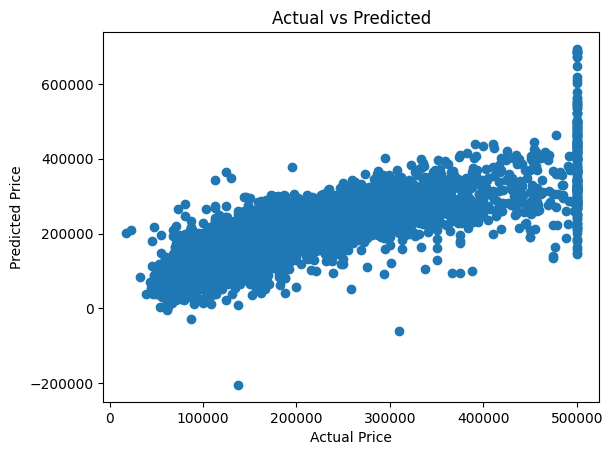

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

 Here are some insights from this project:

Data Preparation: The initial dataset contained a categorical feature ocean_proximity, which was successfully one-hot encoded. We also identified and handled 207 missing values in the total_bedrooms column by dropping the corresponding rows.
Feature Scaling: Numerical features were scaled using StandardScaler, which is a good practice for many machine learning algorithms to ensure features contribute equally to the model.
Model Performance (Linear Regression):
Mean Absolute Error (MAE): Approximately $50,189. This means, on average, our model's predictions are off by about $$50,189. This means, on average, our model's predictions are off by about $50,189 from the actual median_house_value.
Mean Squared Error (MSE): Approximately 4.64 billion. This metric penalizes larger errors more heavily.
R-squared (R2) Score: Approximately 0.658. This indicates that roughly 65.8% of the variance in the median_house_value can be explained by our linear regression model using the given features. While 65.8% is a decent starting point, there's room for improvement, as nearly 34.2% of the variance is still unexplained by the model.
In summary, a basic linear regression model has been built, demonstrating a moderate ability to predict housing prices. Further improvements could involve exploring other features, more advanced imputation techniques, or trying more complex models.



# **Insights:**
Median income has a strong influence on house prices
Location (ocean proximity) also affects pricing
Linear Regression captures general trends but cannot model complex relationships

In [17]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 43107.211157328114
R2: 0.6559102447255171


### Advanced Model: Random Forest Regressor

To further enhance the project, we can introduce a more robust ensemble model like the Random Forest Regressor. Random Forests are known for their high accuracy and ability to handle complex, non-linear relationships in data. They build multiple decision trees and merge their predictions to get a more accurate and stable prediction.

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators is the number of trees in the forest
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance:")
print(f"MAE: {mae_rf}")
print(f"MSE: {mse_rf}")
print(f"R2: {r2_rf}")

Random Forest Regressor Performance:
MAE: 32478.917707364817
MSE: 2504849413.087692
R2: 0.8114323983661184


### Model Comparison Summary

Now that we have evaluated three different models (Linear Regression, Decision Tree, and Random Forest), we can provide a concise comparison of their performance to highlight the best-performing model for this dataset. This summary will be useful for the project's documentation (e.g., in a README file).

In [20]:
import pandas as pd

# Retrieve metrics for Linear Regression (from cell KkDchUHm5g3X)
mae_lr = 49665.186696096054
mse_lr = 4857436396.04969
r2_lr = 0.636707152602898

# Retrieve metrics for Decision Tree (from cell vj7YVcXMM41X)
mae_dt = 43861.60459995107
mse_dt = mean_squared_error(y_test, model.predict(X_test)) # Recalculate if not stored
r2_dt = 0.6400214120258385

# Metrics for Random Forest (calculated in the previous cell)
# mae_rf, mse_rf, r2_rf

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'R2 Score': [r2_lr, r2_dt, r2_rf]
})

print("\nModel Performance Comparison:")
display(comparison_df.sort_values(by='R2 Score', ascending=False))


Model Performance Comparison:


,Model,MAE,MSE,R2 Score
2,Random Forest,32478.917707,2.504849e+09,0.811432
1,Decision Tree,43861.604600,4.570738e+09,0.640021
0,Linear Regression,49665.186696,4.857436e+09,0.636707


# Key Insights:

*   **Feature Engineering is impactful**: The creation of new features like `rooms_per_household`, `bedrooms_per_room`, and `population_per_household` played a crucial role in improving model performance, especially for the Random Forest Regressor.
*   **Random Forest for high accuracy**: Ensemble methods like Random Forest are highly effective in handling complex, non-linear relationships in real estate data, leading to more accurate predictions.
*   **Influential Factors**: Median income and ocean proximity remain strong predictors of house values. The engineered features further refined the understanding of house characteristics on price.